In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline

In [54]:
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df.shape

(10000, 11)

In [55]:
df_original = df.copy()
df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [56]:
df = df[['engine_displacement','horsepower','vehicle_weight','model_year','fuel_efficiency_mpg']]
df.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


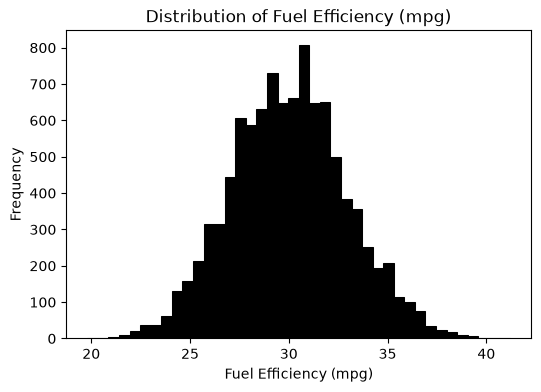

In [57]:
# Exploratory Data Analysis (EDA)
plt.figure(figsize=(6, 4))

sns.histplot(df['fuel_efficiency_mpg'], bins=40, alpha=1, color='black')
plt.ylabel('Frequency')
plt.xlabel('Fuel Efficiency (mpg)')
plt.title('Distribution of Fuel Efficiency (mpg)')

plt.show()


In [58]:
for col in df.columns:
    print(col, df[col].isnull().sum())

for col in df.columns:
    print(col)
    print(df[col].unique())
    print(df[col].nunique())
    print()


engine_displacement 0
horsepower 877
vehicle_weight 0
model_year 0
fuel_efficiency_mpg 0
engine_displacement
[2180 2390 2320 2130 2580 2290 2270 2370 2330 2410 2240 2440 1900 2170
 2280 2540 2490 2300 2350 2610 2160 2260 2010 2460 2080 2070 2620 2560
 2420 2200 2530 2360 2340 2150 2500 2400 2740 2140 2190 1980 1960 2100
 1890 2310 1910 2110 2450 2650 2220 2020 2550 2430 2470 2250 2090 2380
 2230 1820 2510 2210 1920 2120 2040 1930 1880 2480 1780 1670 1950 1940
 2640 2060 2000 2570 2710 2680 1790 2600 1970 2700 1810 2030 2630 2520
 1870 2670 2050 1990 2690 2590 1850 1750 1860 1840 2790 1700 2720 2660
 1800 2960 2750 1760 2830 2820 2760 2780 2730 1710 1720 1830 2910 2940
 1770 1740 2840 1590 1690 3020 2900 2770 3110 1730 2850 1680 2800 3000
 2870]
127

horsepower
[243. 272. 267. 258. 304. 266. 250. 279. 251. 280.  nan 277. 202. 226.
 234. 299. 264. 260. 291. 246. 302. 249. 254. 265. 216. 294. 240. 255.
 273. 270. 262. 296. 239. 248. 282. 238. 231. 289. 232. 321. 235. 257.
 284. 233. 198. 

In [59]:
df.dtypes

engine_displacement      int64
horsepower             float64
vehicle_weight           int64
model_year               int64
fuel_efficiency_mpg    float64
dtype: object

In [60]:
df['horsepower'].median()


np.float64(254.0)

In [81]:

# df = df.fillna(df['horsepower'].median(), inplace=False)
df = df_original.fillna(0, inplace=False)

In [82]:
# validation framework
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [83]:
df_train.shape, df_val.shape, df_test.shape

((6000, 11), (2000, 11), (2000, 11))

In [84]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [85]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [86]:
# Baseline solution
base = ['horsepower', 'engine_displacement', 'vehicle_weight', 'model_year']

In [87]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [88]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

In [89]:
y_pred = w_0 + X_train.dot(w)

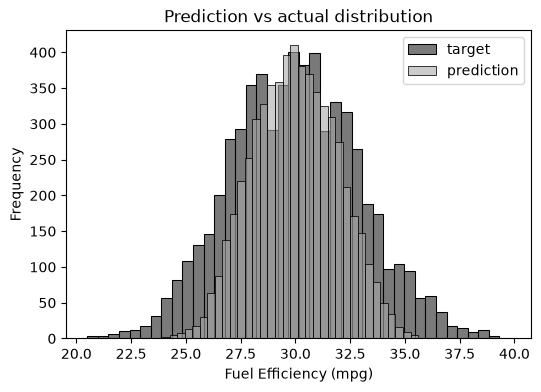

In [90]:
plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color="#222222", alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color="#aaaaaa", alpha=0.6, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Fuel Efficiency (mpg)')
plt.title('Prediction vs actual distribution')

plt.show()

In [91]:
def rmse(y, y_pred):
    error = y - y_pred
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [92]:
rmse(y_train, y_pred)

np.float64(2.200184683371396)

In [93]:
X_val = prepare_X(df_val)
y_pred_val = w_0 + X_val.dot(w)

In [94]:
rmse_val = rmse(y_val, y_pred_val).round(3)
print(rmse_val)


2.205


In [95]:
X_test = prepare_X(df_test)
y_pred_test = w_0 + X_test.dot(w)

In [96]:
rmse(y_test, y_pred_test)

np.float64(2.237846056596626)

In [97]:
# Regularization

df.head()

,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,0.0,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,0.0,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


In [99]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]


In [100]:
X_train = prepare_X(df_train)

In [105]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    print('%5s, %.2f, %.2f, %.2f' % (r, w_0, w[2], w[3]))

    0, -153.88, -0.00, 0.10
 0.01, -148.31, -0.00, 0.10
  0.1, -111.84, -0.00, 0.08
    1, -32.33, -0.00, 0.04
    5, -7.77, -0.00, 0.03
   10, -3.99, -0.00, 0.03
  100, -0.41, -0.00, 0.03


In [110]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    
    X_val = prepare_X(df_val)
    y_pred = w_0 + X_val.dot(w)
    print('regularization: %5s, %4s' % (r, '%.4f' % rmse(y_val, y_pred)))

regularization:     0, 2.2053
regularization:  0.01, 2.2058
regularization:   0.1, 2.2241
regularization:     1, 2.3492
regularization:     5, 2.4094
regularization:    10, 2.4195
regularization:   100, 2.4292


In [111]:
# Question 5
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
scores = []
for seed in seeds:
    # validation framework
    n = len(df)
    n_val = int(n * 0.2)
    n_test = int(n * 0.2)
    n_train = n - n_val - n_test

    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train + n_val]]
    df_test = df.iloc[idx[n_train + n_val:]]

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = prepare_X(df_train)
    w_0, w = train_linear_regression(X_train, y_train)
    y_val_pred = w_0 + prepare_X(df_val).dot(w)
    score = rmse(y_val, y_val_pred)
    print('seed: %s, rmse: %.4f' % (seed, score)) 

    scores.append(rmse(y_val, y_val_pred))

print(round(np.std(scores), 3))

seed: 0, rmse: 2.2392
seed: 1, rmse: 2.2021
seed: 2, rmse: 2.1634
seed: 3, rmse: 2.2044
seed: 4, rmse: 2.2019
seed: 5, rmse: 2.2458
seed: 6, rmse: 2.2697
seed: 7, rmse: 2.1908
seed: 8, rmse: 2.2166
seed: 9, rmse: 2.2070
0.029


In [115]:
# validation framework
n = len(df)
n_val = int(n * 0.2)
n_train = n - n_val 

np.random.seed(9)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train + n_val]]

y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']

X_train = prepare_X(df_train)
w_0, w = train_linear_regression_reg(X_train, y_train, r=0.001)
y_val_pred = w_0 + prepare_X(df_val).dot(w)
score = rmse(y_val, y_val_pred)

print(round(score,3))

2.236
